### Linear Model Selection and Regularization

#### Activity 1

Work in a small group. Once you've completed your analysis, share your findings:

* Identify the features that exhibit high correlation with each other and discuss how these correlations could impact predictive performance.

In [7]:
# Loading libraries

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

pd.set_option('display.max_columns', None)

In [8]:
# Load the dataset and ensure that Ames_numeric-10-binary.csv is located in the same folder as this script.
df_week2 = pd.read_csv("Ames_numeric-10-binary.csv")
df_X = df_week2.drop(columns='SalePrice')
df_y = df_week2['SalePrice']

In [9]:
lr = LinearRegression()

rmse_lr = -cross_val_score(lr, df_X, df_y, cv=5,scoring='neg_root_mean_squared_error')
print("RMSE: %0.2f ; Standard deviation : %0.2f" % (rmse_lr.mean(), rmse_lr.std()))

RMSE: 26501.39 ; Standard deviation : 2756.29


<Axes: >

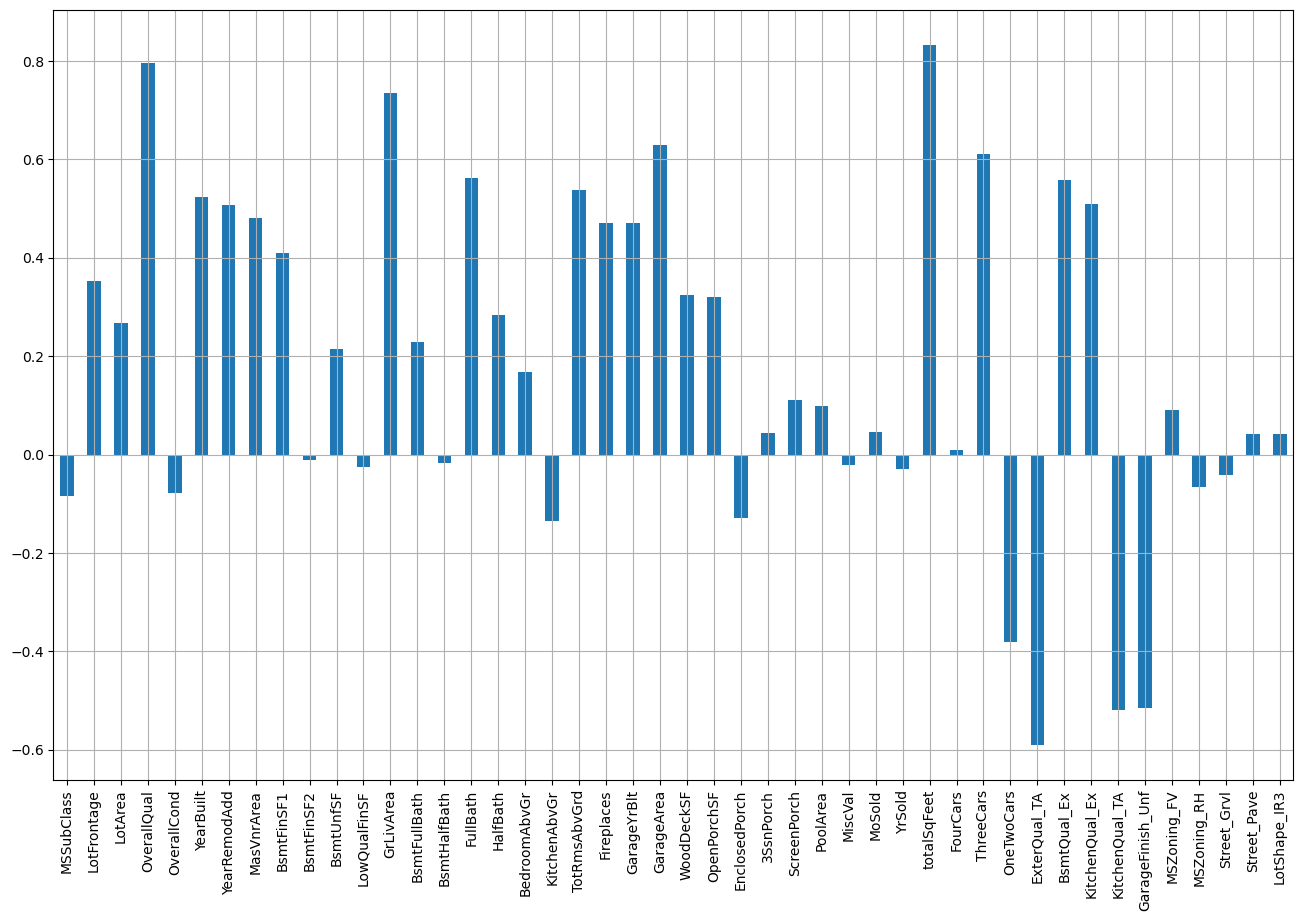

In [10]:
# Review the correlations between the features and the target variable

df_X.corrwith(df_y).plot.bar(figsize=(16, 10), grid=True)

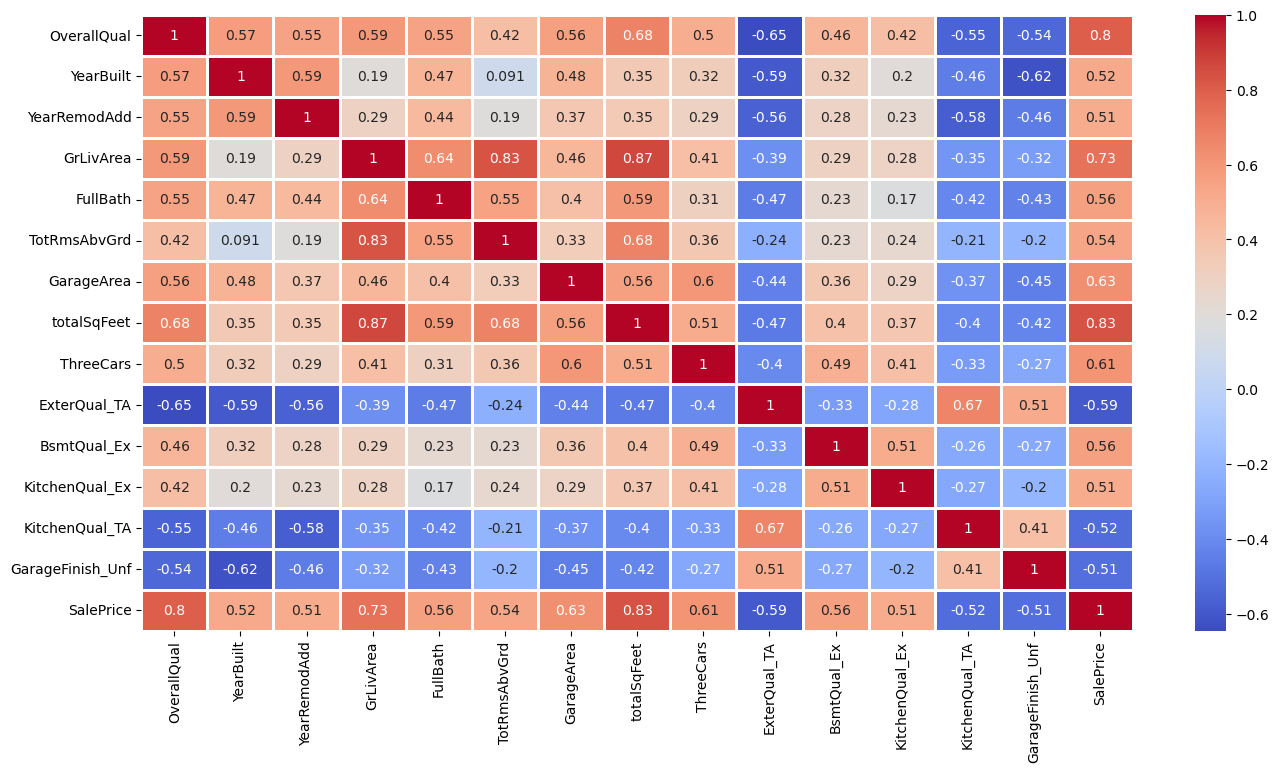

In [11]:
# Your task: conduct correlation analysis between the features or use a method of your choice.
high_corr = df_week2.corr()
high_corr_features = high_corr.index[abs(high_corr['SalePrice']) > 0.5]
plt.figure(figsize=(16,8))
ax = sns.heatmap(data=df_week2[high_corr_features].corr(), annot=True, cmap='coolwarm', linewidths=2)

Activity 2:

Work in a small group. Once you've completed your analysis, share your findings:
* Task 2.1 Compare forward and backward subset selection method on Ames dataset, discuss the Pros and Cons of both methods.

__[Mlxtend](https://rasbt.github.io/mlxtend/user_guide/feature_selection/SequentialFeatureSelector/)__ implements feature subset selection by adding or removing one feature at a time until a feature subset of the desired size _k_ is reached.

#### Sequential Forward Selection
Let _J(X)_ denote the scoring function based on the dataset _X_, the algorithm at Step _k_ is given as:

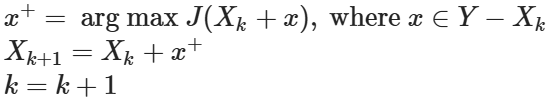

It converges until the desired size _k_ is reached.

#### Sequential Backward Selection

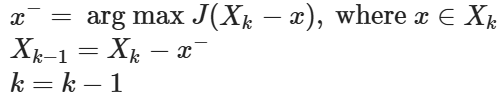

It converges until the desired size _k_ is reached.

In [12]:
from mlxtend.feature_selection import SequentialFeatureSelector

# Forward feature selection
regfit_fwd = SequentialFeatureSelector(lr, k_features=30, forward=True, 
scoring='neg_mean_squared_error', cv=5)
regfit_fwd.fit(df_X, df_y)

selected_indices = regfit_fwd.k_feature_idx_

In [13]:
regfit_fwd.k_feature_names_

('MSSubClass',
 'LotFrontage',
 'LotArea',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'GrLivArea',
 'BsmtHalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'Fireplaces',
 'GarageYrBlt',
 'WoodDeckSF',
 'ScreenPorch',
 'totalSqFeet',
 'FourCars',
 'ThreeCars',
 'ExterQual_TA',
 'BsmtQual_Ex',
 'KitchenQual_Ex',
 'KitchenQual_TA',
 'MSZoning_FV',
 'MSZoning_RH',
 'Street_Grvl',
 'Street_Pave',
 'LotShape_IR3')

In [14]:
fwd_lr = -cross_val_score(lr, df_X.iloc[:,list(selected_indices)], df_y, cv=5,scoring='neg_root_mean_squared_error')
print("RMSE: %0.2f ; Standard deviation : %0.2f" % (fwd_lr.mean(), fwd_lr.std()))

RMSE: 25891.45 ; Standard deviation : 2568.65


* Task 2.2 What are the differences between SequentialFeatureSelector and the forward/backward subset selection methods introduced in this lecture?

Activity 3:

Work in a small group. Once you've completed your analysis, share your findings:

* Try both __[Ridge](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html)__ and __[Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html)__ on Ames, compare the differences in terms of their weights.

In [15]:
from sklearn.linear_model import Ridge, RidgeCV, Lasso

In [16]:
ridge_reg = Ridge(alpha=1)

cv_ridge = -cross_val_score(ridge_reg, df_X, df_y, cv=5,scoring='neg_root_mean_squared_error')
print("RMSE: %0.2f ; Standard deviation : %0.2f" % (cv_ridge.mean(), cv_ridge.std()))

RMSE: 26498.77 ; Standard deviation : 2757.05


In [17]:
lasso_reg = Lasso(alpha=5)

cv_lasso = -cross_val_score(lasso_reg, df_X, df_y, cv=5,scoring='neg_root_mean_squared_error')
print("RMSE: %0.2f ; Standard deviation : %0.2f" % (cv_lasso.mean(), cv_lasso.std()))

RMSE: 26496.95 ; Standard deviation : 2753.89


C:\Users\quliz\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.709e+11, tolerance: 7.592e+08
  model = cd_fast.enet_coordinate_descent(
C:\Users\quliz\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.792e+11, tolerance: 7.285e+08
  model = cd_fast.enet_coordinate_descent(
C:\Users\quliz\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.290e+11, toleranc

In [18]:
ridge_reg.fit(df_X, df_y)
lasso_reg.fit(df_X, df_y)

C:\Users\quliz\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.578e+11, tolerance: 9.207e+08
  model = cd_fast.enet_coordinate_descent(


Lasso(alpha=5)

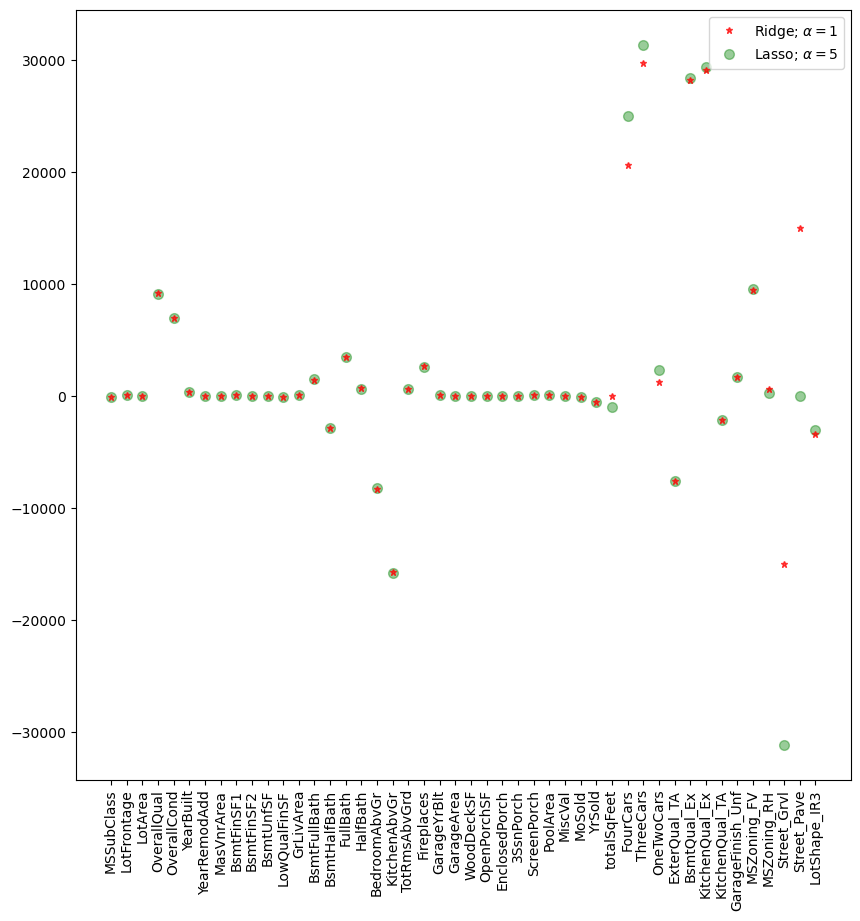

In [19]:
plt.figure(figsize = (10, 10))
plt.plot(df_X.columns,ridge_reg.coef_,alpha=0.7,linestyle='none',marker='*',markersize=5,color='red',label=r'Ridge; $\alpha = 1$',zorder=7)
plt.plot(df_X.columns,lasso_reg.coef_,alpha=0.4,linestyle='none',marker='o',markersize=7,color='green',label=r'Lasso; $\alpha = 5$')
plt.xticks(rotation = 90)
plt.legend()
plt.show()

# https://www.datacamp.com/tutorial/tutorial-lasso-ridge-regression